# Predicting the Hability of Exoplanets using Machine Learning

# Motivation

For my final project, I wish to combine the teachings of this course with another area of interest to me: astronomy. Since decades now, we have been collecting data about other star-planet systems in our galaxy, and since decades we have wondered if any of those planets could one day inhabit human life... or possibly even already have alien life of it's own. This, however is not an easy problem. While planets around stars are not rare and astronomers theorize that there might be orders of magnitude more planets than stars, a planet being habitable is quite another thing. The conditions need to be just right for life to develop and specifically for human life to be sustained. There has been a lot of study into what factors can be considered about the planets while trying to answer whether or not it can be hospitable. I shall be citing two of these and another project that delve into this topic towards the end of the notebook. A problem with astronomical data is that there is a lot of noise and possibility of error, secondly, as I mentioned above, whether or not a planet is habitable or not involved a lot of different factors, making it quite a complex problem to solve. While there is a mathematical way to solve it, this is quite time consuming and considering that there are more than hundreds of new exoplanets (maybe more!) being discovered every year, keeping in mind all the different factors about the planet and then determining for each one of them whether they are habitable or not can be quite tedious. However, considering that most of this information is numeric and involves calculation makes it an ideal candidate for a Machine Learning problem. This not only solves the time of the researchers but if we have a fair estimate based on a subset of prior, easy to collect data about whether or not a planet might be habitable, more research and observations can be focused on those to gather further valuable information about it. Thus, even a rudimentary machine learning solution that helps to give a temporary classification can be greatly useful for further research and progress. Hence, my goal for this project is to focus on the "primary" data that we can easily get about the planet just by observing the system (its size, an estimate of its surface temperature, the size of the star it orbits and so on) and use those rudimentary features in order to classify the planet as habitable or inhabitable. The reduction of data is both for a challenge and an in depth look into what features are important and which ones are not. The inspiration for this project is a study I shall cite towards the end as well as one more study and a project that helped me with collecting the data and understanding the concepts. Plus, I am way too inspired by science fiction movies where astronauts look at preliminary information about the planets and say: "World - Habitable!" - I hope one day this replication gets to a level of advancement where it can be used for such fast predictions accurately!

Thus, the problem I am tackling is is to use these preliminary features that can be obtained by a telescope for an exoplanet and predict a categorical variable that states whether the planet is habitable or not!

# About the Data and Outcome

The data used here is taken from Kepler's Public Data Repository of Exoplanets. There were two data sources initially being planned to be used but I decided to go with just one of them. But for the sake of posteriety, I shall also mention that the other dataset I was planning on using was from Puerto Rico's Planetary Habitability Laboratory's Exoplanet Catalog. The current API for the data that I am using is a little bit outdated and slow, however it's documentation can be found here: https://exoplanetarchive.ipac.caltech.edu/docs/API_kepcandidate_columns.html

I took the dataset from a similar machine learning project that had already scraped the data and cleaned it. I can attest to the fact that the project in question despite using Machine Learning was quite different from what I am working on here. 


The data involved is titled "Kepler Object of Interest" (koi for future reference) cumulative dataset. It contains various data collected about exoplanets that were discovered by the Kepler Mission. These contain the features of our interest here and along side them other information such as the planet's location relative to the Earth, it's velocity in the galaxy, the spectra of the star, so on and so forth. The information I shall be using for my work will be all numeric -- and the outcome variable here will be **Categorical**. 

The outcome would essentially just be whether or not a planet is habitable -- a binary outcome. 

The predictors however are all numerical and they are as follows:

1. koi_period: Orbital period of the exoplanet moving around its star (in days)

2. koi_eccen: Orbital eccentricity — how elongated the exoplanet’s orbit is

3. koi_ror: Planet-star radius ratio — ratio of the planet’s radius to the star’s radius

4. koi_srho: Fitted stellar density (in g/cm³) — density of the host star as derived from transit data

5. koi_prad: Planetary radius (in Earth radii) — size of the exoplanet relative to Earth

6. koi_sma: Orbit semi-major axis (in AU) — average distance between the planet and the star

7. koi_teq: Equilibrium temperature (in K) — estimated temperature of the planet assuming radiative balance

8. koi_insol: Insolation flux (in Earth flux units) — amount of stellar radiation the planet receives

9. koi_dor: Planet-star distance over star radius — geometric transit parameter

10. koi_count: Number of planets detected around the same star

11. koi_steff: Stellar effective temperature (in K) — temperature of the star’s photosphere

12. koi_slogg: Stellar surface gravity (log₁₀(cm/s²)) — measure of gravitational pull at the star's surface

13. koi_smet: Stellar metallicity (dex) — abundance of elements heavier than hydrogen and helium in the star

14. koi_srad: Stellar radius (in solar radii) — size of the star compared to the Sun

15. koi_smass: Stellar mass (in solar masses) — mass of the star compared to the Sun


As you might notice, all of these features are the primary features one gleans about a planet based on observations and they will be forming the basis of my analysis. They are all numeric, with a bunch of outliers, and I shall be exploring them in the next section.

The entire dataset is divided into 3 dataframes -- firstly the cumulative data about the exoplanets and kepler objects of interest -- this has a myriad of information about various astronomical objects including large asteroids and dwarf planets and so on and so forth. The second dataset consists of planets that scientists have already classified has habitable and are confirmed to be planets and the third and final dataset consists of confirmed planets which are also confirmed to be inhabitable. Using these 3 datasets we shall be creating our dataset on which we will be performing machine learning. This dataset consists of ~2000+ planets and 15 features regarding them. More on it in the EDA section.

# Exploratory Data Analysis

## Setup 
Adding required libraries and importing the dataset

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt # plotting

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.metrics import f1_score
from sklearn.decomposition import PCA
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor

/kaggle/input/exoplanets-dataset/habitable_planets_detailed_list.xlsx
/kaggle/input/exoplanets-dataset/non_habitable_planets_confirmed_detailed_list.xlsx
/kaggle/input/exoplanets-dataset/cumulative-exoplanets.xlsx


Importing the exoplanets data

In [2]:
exoplanets_df = pd.read_excel('/kaggle/input/exoplanets-dataset/cumulative-exoplanets.xlsx', sheet_name='cumulative')

In [3]:
exoplanets_df

,rowid,kepid,kepoi_name,kepler_name,koi_disposition,koi_vet_stat,koi_vet_date,koi_pdisposition,koi_score,koi_fpflag_nt,...,koi_dicco_mdec,koi_dicco_mdec_err,koi_dicco_msky,koi_dicco_msky_err,koi_dikco_mra,koi_dikco_mra_err,koi_dikco_mdec,koi_dikco_mdec_err,koi_dikco_msky,koi_dikco_msky_err
0,1,10797460,K00752.01,Kepler-227 b,CONFIRMED,Active,2017-05-10,CANDIDATE,1.000,0,...,0.200,0.160,0.200,0.170,0.080,0.130,0.310,0.170,0.320,0.160
1,2,10797460,K00752.02,Kepler-227 c,CONFIRMED,Active,2017-05-10,CANDIDATE,0.969,0,...,0.000,0.480,0.390,0.360,0.490,0.340,0.120,0.730,0.500,0.450
2,3,10811496,K00753.01,NaN,FALSE POSITIVE,Active,2017-05-10,FALSE POSITIVE,0.000,0,...,-0.034,0.070,0.042,0.072,0.002,0.071,-0.027,0.074,0.027,0.074
3,4,10848459,K00754.01,NaN,FALSE POSITIVE,Active,2017-05-10,FALSE POSITIVE,0.000,0,...,0.147,0.078,0.289,0.079,-0.257,0.072,0.099,0.077,0.276,0.076
4,5,10854555,K00755.01,Kepler-664 b,CONFIRMED,Active,2017-05-10,CANDIDATE,1.000,0,...,-0.090,0.180,0.100,0.140,0.070,0.180,0.020,0.160,0.070,0.200
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9559,9560,10031643,K07984.01,NaN,FALSE POSITIVE,Active,2017-05-10,FALSE POSITIVE,0.000,0,...,-1.200,1.000,1.750,0.820,1.350,0.600,-1.300,1.000,1.840,0.810
9560,9561,10090151,K07985.01,NaN,FALSE POSITIVE,Active,2017-05-10,FALSE POSITIVE,0.000,0,...,-1.757,0.068,2.763,0.074,2.344,0.072,-1.756,0.068,2.929,0.072
9561,9562,10128825,K07986.01,NaN,CANDIDATE,Active,2017-05-10,CANDIDATE,0.497,0,...,-0.250,0.490,0.780,0.460,0.500,0.400,-0.180,0.470,0.530,0.470
9562,9563,10147276,K07987.01,NaN,FALSE POSITIVE,Active,2017-05-10,FALSE POSITIVE,0.021,0,...,-3.650,0.260,5.000,0.220,3.380,0.160,-3.890,0.260,5.160,0.220


In [4]:
print("Number of rows:", len(exoplanets_df))
print("Number of columns:", len(exoplanets_df.columns))


Number of rows: 9564
Number of columns: 141


## Note

Eventhough the original data has rougly 141 columns, we will not be using all of them and only concentrating on data that according to the literature is relevant to the problem. Thus the final dataset and it's details shall be discussed further ahead

Importing data and IDs of the habitable planets (rare)

In [5]:
habitable_df = pd.read_excel("/kaggle/input/exoplanets-dataset/habitable_planets_detailed_list.xlsx")

In [6]:
habitable_df

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pan

,rowid,kepid,kepoi_name,kepler_name,koi_disposition,koi_vet_stat,koi_vet_date,koi_pdisposition,koi_score,koi_fpflag_nt,...,koi_dicco_mdec,koi_dicco_mdec_err,koi_dicco_msky,koi_dicco_msky_err,koi_dikco_mra,koi_dikco_mra_err,koi_dikco_mdec,koi_dikco_mdec_err,koi_dikco_msky,koi_dikco_msky_err
0,2038,8890150,K02650.01,Kepler-395 c,CONFIRMED,Active,2017-05-10,CANDIDATE,0.985,0,...,-0.50,0.56,0.53,0.57,0.39,0.37,-0.26,0.48,0.47,0.43
1,4688,6497146,K03284.01,Kepler-438 b,CONFIRMED,Active,2017-05-10,CANDIDATE,1.000,0,...,-0.03,0.33,0.28,0.42,-0.48,0.42,0.00,0.33,0.48,0.42
2,7542,9480398,K07179.01,NaN,CANDIDATE,Active,2015-09-18,CANDIDATE,NaN,0,...,0.90,2.60,1.90,3.00,1.80,2.70,0.90,4.30,2.10,4.50
3,2617,3642335,K03010.01,Kepler-1410 b,CONFIRMED,Active,2017-05-10,CANDIDATE,0.996,0,...,-0.56,0.73,0.62,0.79,0.51,0.48,-0.21,0.37,0.55,0.47
4,4649,4138008,K04742.01,Kepler-442 b,CONFIRMED,Active,2017-05-10,CANDIDATE,0.993,0,...,-0.11,0.60,0.19,0.89,0.21,0.79,-0.45,0.86,0.50,0.84
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
121,9180,9084569,K07923.01,NaN,CANDIDATE,Active,2017-05-10,CANDIDATE,0.750,0,...,-0.24,0.60,1.50,1.60,1.30,1.40,-0.33,0.63,1.40,1.50
122,9362,9650762,K07954.01,NaN,CANDIDATE,Active,2017-05-10,CANDIDATE,0.839,0,...,-1.80,0.26,1.92,0.26,-0.52,0.30,-1.73,0.26,1.81,0.26
123,9001,10331279,K08000.01,NaN,CANDIDATE,Active,2017-05-10,CANDIDATE,0.975,0,...,0.10,1.10,1.60,1.10,-1.60,1.00,0.05,0.59,1.60,1.00
124,9064,10452252,K08012.01,NaN,CANDIDATE,Active,2017-05-10,CANDIDATE,0.989,0,...,0.18,0.76,0.18,0.71,0.05,0.93,1.51,0.70,1.51,0.71


Importing data and IDs of the non habitable planets

In [7]:
non_habitable_df = pd.read_excel("/kaggle/input/exoplanets-dataset/non_habitable_planets_confirmed_detailed_list.xlsx")

In [8]:
non_habitable_df

,rowid,kepid,kepoi_name,kepler_name,koi_disposition,koi_vet_stat,koi_vet_date,koi_pdisposition,koi_score,koi_fpflag_nt,...,koi_dicco_mdec,koi_dicco_mdec_err,koi_dicco_msky,koi_dicco_msky_err,koi_dikco_mra,koi_dikco_mra_err,koi_dikco_mdec,koi_dikco_mdec_err,koi_dikco_msky,koi_dikco_msky_err
0,1,10797460,K00752.01,Kepler-227 b,CONFIRMED,Active,2017-05-10,CANDIDATE,1.000,0,...,0.20,0.16,0.20,0.17,0.08,0.13,0.31,0.17,0.32,0.16
1,2,10797460,K00752.02,Kepler-227 c,CONFIRMED,Active,2017-05-10,CANDIDATE,0.969,0,...,0.00,0.48,0.39,0.36,0.49,0.34,0.12,0.73,0.50,0.45
2,5,10854555,K00755.01,Kepler-664 b,CONFIRMED,Active,2017-05-10,CANDIDATE,1.000,0,...,-0.09,0.18,0.10,0.14,0.07,0.18,0.02,0.16,0.07,0.20
3,6,10872983,K00756.01,Kepler-228 d,CONFIRMED,Active,2017-05-10,CANDIDATE,1.000,0,...,-0.07,0.11,0.08,0.13,-0.02,0.13,-0.08,0.10,0.08,0.10
4,7,10872983,K00756.02,Kepler-228 c,CONFIRMED,Active,2017-05-10,CANDIDATE,1.000,0,...,0.09,0.16,0.26,0.16,0.18,0.15,0.06,0.15,0.19,0.17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2241,9310,7347246,K03014.01,Kepler-1411 b,CONFIRMED,Active,2017-05-10,CANDIDATE,0.941,0,...,0.05,0.32,0.17,0.34,0.07,0.29,-0.03,0.31,0.07,0.35
2242,9354,8895758,K03106.01,Kepler-1427 b,CONFIRMED,Active,2017-05-10,CANDIDATE,0.877,0,...,-0.74,0.59,0.75,0.60,0.14,0.38,-0.64,0.56,0.65,0.57
2243,9356,6196457,K00285.03,Kepler-92 d,CONFIRMED,Active,2017-05-10,FALSE POSITIVE,0.476,1,...,-0.47,0.48,0.56,0.42,-0.17,0.20,-0.28,0.49,0.32,0.43
2244,9480,7503885,K03417.01,Kepler-1494 b,CONFIRMED,Active,2017-05-10,CANDIDATE,1.000,0,...,-0.17,0.35,0.21,0.59,-0.10,0.64,0.02,0.39,0.11,0.56


Next, I'm filtering out the main dataframe to keep only the relevant features. Below is a list of the features I will be keeping and what each and every one of those features mean in plain text. 

In [9]:
## Keeping only the relevant columns

# Define the list of columns to keep
columns_to_keep = [

    "kepoi_name",    # specific planet name
    "koi_period",    # Orbital Period [days]
    "koi_eccen",     # Orbital eccentricity
    "koi_ror",       # Planet-Star Radius Ratio
    "koi_srho",      # Fitted Stellar Density [g/cm**3]
    "koi_prad",      # Planetary Radius [Earth radii]
    "koi_sma",       # Orbit Semi-Major Axis [AU]
    "koi_teq",       # Equilibrium Temperature [K]
    "koi_insol",     # Insolation Flux [Earth flux]
    "koi_dor",       # Planet-Star Distance over Star Radius
    "koi_count",     # Number of Planets
    "koi_steff",     # Stellar Effective Temperature [K]
    "koi_slogg",     # Stellar Surface Gravity [log10(cm/s**2)]
    "koi_smet",      # Stellar Metallicity [dex]
    "koi_srad",      # Stellar Radius [Solar radii]
    "koi_smass",     # Stellar Mass [Solar mass]
    
]

In [10]:
# Keep only the specified columns in the DataFrame
exoplanets_df = exoplanets_df[columns_to_keep]

In [11]:
exoplanets_df

,kepoi_name,koi_period,koi_eccen,koi_ror,koi_srho,koi_prad,koi_sma,koi_teq,koi_insol,koi_dor,koi_count,koi_steff,koi_slogg,koi_smet,koi_srad,koi_smass
0,K00752.01,9.488036,0.0,0.022344,3.20796,2.26,0.0853,793.0,93.59,24.810,2,5455.0,4.467,0.14,0.927,0.919
1,K00752.02,54.418383,0.0,0.027954,3.02368,2.83,0.2734,443.0,9.11,77.900,2,5455.0,4.467,0.14,0.927,0.919
2,K00753.01,19.899140,0.0,0.154046,7.29555,14.60,0.1419,638.0,39.30,53.500,1,5853.0,4.544,-0.18,0.868,0.961
3,K00754.01,1.736952,0.0,0.387394,0.22080,33.46,0.0267,1395.0,891.96,3.278,1,5805.0,4.564,-0.52,0.791,0.836
4,K00755.01,2.525592,0.0,0.024064,1.98635,2.75,0.0374,1406.0,926.16,8.750,1,6031.0,4.438,0.07,1.046,1.095
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9559,K07984.01,8.589871,0.0,0.009364,0.18863,1.11,0.0779,929.0,176.40,9.030,1,5638.0,4.296,-0.16,1.088,0.856
9560,K07985.01,0.527699,0.0,0.297633,0.16318,29.35,0.0128,2088.0,4500.53,1.339,1,5638.0,4.529,0.14,0.903,1.005
9561,K07986.01,1.739849,0.0,0.006379,0.50770,0.72,0.0290,1608.0,1585.81,4.331,1,6119.0,4.444,-0.04,1.031,1.075
9562,K07987.01,0.681402,0.0,0.009444,8.97692,1.07,0.0157,2218.0,5713.41,6.040,1,6173.0,4.447,-0.04,1.041,1.104


Adding the target variable to the relevant tables

Only keeping the data regarding the planet ID and whether or not it is habitable because that is the only data required for our analysis

In [12]:
habitable_df['habitable?'] = 1 # This adds a variable to the habitable planets indicating them as habitable -- we are constructing the target variable

non_habitable_df['habitable?'] = 0 # Same as above for non habitable planets

In [13]:
## Columns to keep in the habitability data

cols_to_keep_habitable = [

    "kepoi_name",
    "habitable?"
]

In [14]:
# Filtering

habitable_df = habitable_df[cols_to_keep_habitable]

non_habitable_df = non_habitable_df[cols_to_keep_habitable]

In [15]:
habitable_df

,kepoi_name,habitable?
0,K02650.01,1
1,K03284.01,1
2,K07179.01,1
3,K03010.01,1
4,K04742.01,1
...,...,...
121,K07923.01,1
122,K07954.01,1
123,K08000.01,1
124,K08012.01,1


In [16]:
non_habitable_df

,kepoi_name,habitable?
0,K00752.01,0
1,K00752.02,0
2,K00755.01,0
3,K00756.01,0
4,K00756.02,0
...,...,...
2241,K03014.01,0
2242,K03106.01,0
2243,K00285.03,0
2244,K03417.01,0


In [17]:
## Merging the dataset of habitable and non habitable planets (Vertical merge)

merged_planets_df = pd.concat([habitable_df, non_habitable_df], ignore_index=True)


In [18]:
merged_planets_df

,kepoi_name,habitable?
0,K02650.01,1
1,K03284.01,1
2,K07179.01,1
3,K03010.01,1
4,K04742.01,1
...,...,...
2367,K03014.01,0
2368,K03106.01,0
2369,K00285.03,0
2370,K03417.01,0


 Performing a right join of the exoplanets data with the merged data that includes the target variable. This will form the complete dataset that we shall use in order to train the ML model

In [19]:


exoplanets_filtered_df = pd.merge(exoplanets_df, merged_planets_df, on='kepoi_name', how='right')


In [20]:
exoplanets_filtered_df ## This is the extracted dataset that will be the primary dataset that I will be using for the project

,kepoi_name,koi_period,koi_eccen,koi_ror,koi_srho,koi_prad,koi_sma,koi_teq,koi_insol,koi_dor,koi_count,koi_steff,koi_slogg,koi_smet,koi_srad,koi_smass,habitable?
0,K02650.01,34.989785,0.0,0.020074,4.19621,1.14,0.1691,292.0,1.71,64.7600,2,3765.0,4.725,0.02,0.521,0.526,1
1,K03284.01,35.233069,0.0,0.016941,6.12686,0.97,0.1729,288.0,1.62,73.8000,1,3749.0,4.743,0.16,0.524,0.554,1
2,K07179.01,407.146560,0.0,0.008994,0.08531,1.18,1.0765,272.0,1.29,90.8000,1,5845.0,4.282,0.02,1.198,1.001,1
3,K03010.01,60.866097,0.0,0.024307,6.48899,1.39,0.2465,244.0,0.84,108.3150,1,3808.0,4.734,-0.02,0.522,0.539,1
4,K04742.01,112.303136,0.0,0.020068,4.53694,1.30,0.3874,241.0,0.79,144.6000,1,4401.0,4.677,-0.38,0.595,0.613,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2367,K03014.01,86.116089,0.0,0.027076,3.53765,3.11,0.4001,441.0,8.93,111.5200,1,6161.0,4.454,0.07,1.053,1.150,0
2368,K03106.01,0.968981,0.0,0.009916,2.44940,1.08,0.0197,1844.0,2730.51,4.9539,1,5866.0,4.473,0.18,1.000,1.083,0
2369,K00285.03,49.356791,0.0,0.010449,0.29070,1.91,0.2754,637.0,38.86,33.4500,3,5862.0,4.050,0.16,1.670,1.142,0
2370,K03417.01,91.078624,0.0,0.029618,0.08704,3.26,0.3982,415.0,7.02,33.7000,1,5915.0,4.437,-0.02,1.008,1.014,0


## EDA

In [21]:
exoplanets_filtered_df.shape

(2372, 17)

As seen above, the cleaned data/data subset I am working with has 2372 rows and 17 columns, considering that one of them is the ID of the planet (planet name) and another is the target variable, this leaves us with 15 relevant features to work with

In [22]:


## Checking for empty values


exoplanets_filtered_df.isnull().sum()



kepoi_name    0
koi_period    0
koi_eccen     1
koi_ror       1
koi_srho      1
koi_prad      1
koi_sma       1
koi_teq       1
koi_insol     1
koi_dor       1
koi_count     0
koi_steff     1
koi_slogg     1
koi_smet      1
koi_srad      1
koi_smass     1
habitable?    0
dtype: int64

There's only 1 missing value in certain columns. This should ideally not be a challenge while working with the data. However I shall be performing median imputation later in order to deal with it. Even if all the rows are missing from one of the planet's data, it should not create a problem since there is just one missing value

In [23]:
print("Number of rows:", len(exoplanets_filtered_df))
print("Number of columns:", len(exoplanets_filtered_df.columns))

Number of rows: 2372
Number of columns: 17


### Boxplots of various features to see outliers and a general overview of the data

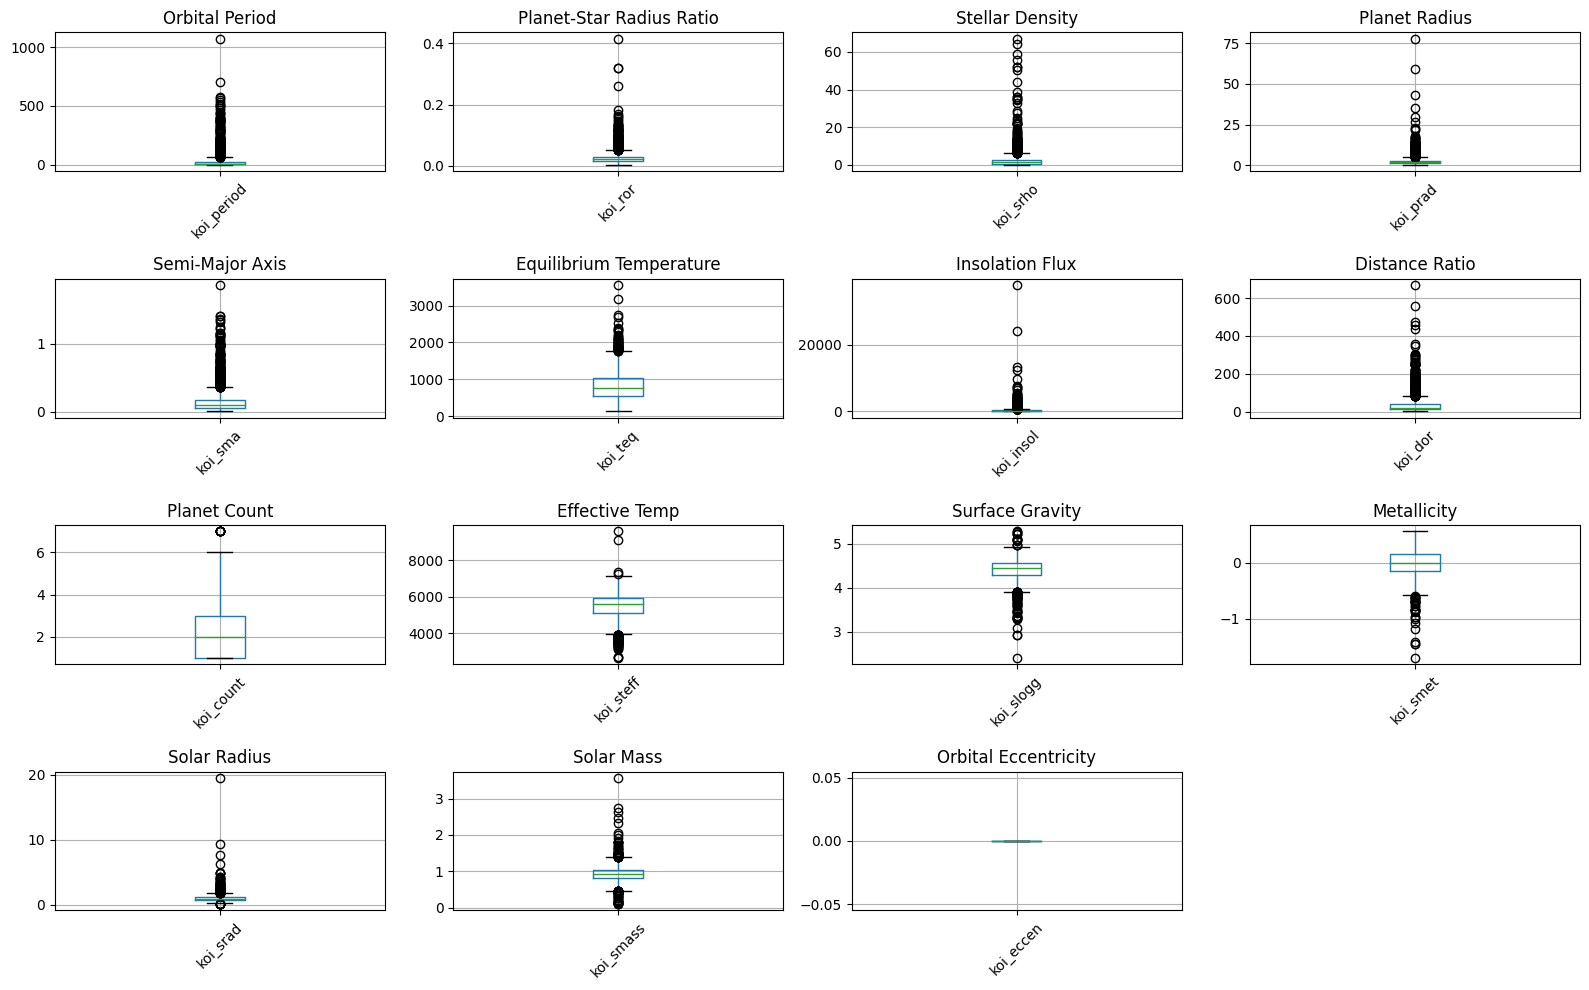

In [24]:
## Distribution of numerical columns


columns_to_plot = [
    "koi_period", "koi_ror", "koi_srho", "koi_prad",
    "koi_sma", "koi_teq", "koi_insol", "koi_dor",
    "koi_count", "koi_steff", "koi_slogg", "koi_smet",
    "koi_srad", "koi_smass", "koi_eccen"
]

# Create subplots (3 rows, 4 columns)
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(16, 10))
axes = axes.flatten()  # Flatten the grid to loop easily

columns_titles = [
    "Orbital Period", "Planet-Star Radius Ratio", "Stellar Density",
    "Planet Radius", "Semi-Major Axis", "Equilibrium Temperature",
    "Insolation Flux", "Distance Ratio", "Planet Count",
    "Effective Temp", "Surface Gravity", "Metallicity", "Solar Radius",
    "Solar Mass", "Orbital Eccentricity"
]

# Plot each boxplot
for i, col in enumerate(columns_to_plot):
    exoplanets_filtered_df.boxplot(column=col, ax=axes[i])
    axes[i].set_title(columns_titles[i])
    axes[i].tick_params(axis='x', labelrotation=45)

# Remove any unused subplots (if fewer than 12)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

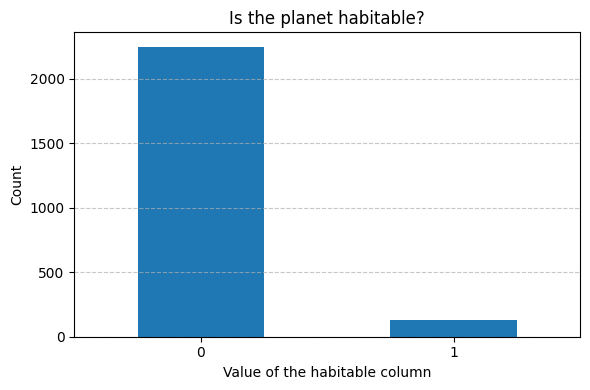

In [25]:
# Count the occurrences of each category
counts = exoplanets_filtered_df['habitable?'].value_counts()

# Plot the bar chart
counts.plot(kind='bar', figsize=(6, 4))
plt.title('Is the planet habitable?')
plt.xlabel('Value of the habitable column')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

As one can see above, the target variable is categorical and unbalanced in terms of its distribution. Thus Macro F1 score might be more useful in order to determine the accuracy of the model

Secondly, it can be seen from the boxplots that a lot of the plots contain outliers. However, I shall only be removing outliers from 2 of the features -- namely solar mass and planet radius. This is because in my literature review, these two were cited to be the most impactful of features. Secondly, if you look at the other variables -- such as distance of the planet (Semi Major Axis) -- you want that distance to be 1 -- since it is measured in AU. This is because empirically, we know that the Earth is 1 AU away from the sun and thus other planets might require that distance to be habitable. Thus, in fact removing outliers there would be removing crucial information. The same would happen with the equillibrium temperature and surface gravity. Since the gravity is measured in log(cm/s^2), the value for earth would be 3 and we want values similar to earth (closer to 3 which are outliers) to be present in the dataset to weed out the habitable planets. There are similar explanations for all the different other variables for which I am not removing the outliers

# Evaluation Metric

As mentioned above, the target variable is highly imbalanced. Thus, we would require a metric that gives classes equal weightage. For those reasons, I will be using Macro F1 score as my evaluation metric for the models.

# Model Fitting

Note that I shall be writing an evaluation of all the models at the very end

## Outliers

In [26]:
def remove_outliers_iqr(df, column, multiplier):
    """
    Removes outliers from the DataFrame based on the IQR method for the specified column.

    """
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - multiplier * IQR
    upper_bound = Q3 + multiplier * IQR
    df_modified = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

    
    print(f"Original rows: {len(df)}")
    print(f"Cleaned rows: {len(df_modified)}")

    return df_modified


In [27]:
## Features that need to be cleaned

## Solar Mass

## Planet Radius


In [28]:
# Cleaning outliers for solar mass
exoplanets_filtered_df_processed = remove_outliers_iqr(exoplanets_filtered_df, 'koi_smass', 1.5)


Original rows: 2372
Cleaned rows: 2276


/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in greater_equal
  return op(a, b)
/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in less_equal
  return op(a, b)


In [29]:
# Planet Radius
exoplanets_filtered_df_processed = remove_outliers_iqr(exoplanets_filtered_df_processed, 'koi_prad', 2)

Original rows: 2276
Cleaned rows: 2121


In [30]:
features_considered = [
    "koi_period", "koi_ror", "koi_srho", "koi_prad",
    "koi_sma", "koi_teq", "koi_insol", "koi_dor",
    "koi_count", "koi_steff", "koi_slogg", "koi_smet",
    "koi_srad", "koi_smass", "koi_eccen"
] ## Features considered in the model



## Train-Test Split

Note that I am doing an 80-20 split on the dataset

In [31]:
X = exoplanets_filtered_df_processed[features_considered]

In [32]:
X

,koi_period,koi_ror,koi_srho,koi_prad,koi_sma,koi_teq,koi_insol,koi_dor,koi_count,koi_steff,koi_slogg,koi_smet,koi_srad,koi_smass,koi_eccen
0,34.989785,0.020074,4.19621,1.14,0.1691,292.0,1.71,64.7600,2,3765.0,4.725,0.02,0.521,0.526,0.0
1,35.233069,0.016941,6.12686,0.97,0.1729,288.0,1.62,73.8000,1,3749.0,4.743,0.16,0.524,0.554,0.0
2,407.146560,0.008994,0.08531,1.18,1.0765,272.0,1.29,90.8000,1,5845.0,4.282,0.02,1.198,1.001,0.0
3,60.866097,0.024307,6.48899,1.39,0.2465,244.0,0.84,108.3150,1,3808.0,4.734,-0.02,0.522,0.539,0.0
4,112.303136,0.020068,4.53694,1.30,0.3874,241.0,0.79,144.6000,1,4401.0,4.677,-0.38,0.595,0.613,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2367,86.116089,0.027076,3.53765,3.11,0.4001,441.0,8.93,111.5200,1,6161.0,4.454,0.07,1.053,1.150,0.0
2368,0.968981,0.009916,2.44940,1.08,0.0197,1844.0,2730.51,4.9539,1,5866.0,4.473,0.18,1.000,1.083,0.0
2369,49.356791,0.010449,0.29070,1.91,0.2754,637.0,38.86,33.4500,3,5862.0,4.050,0.16,1.670,1.142,0.0
2370,91.078624,0.029618,0.08704,3.26,0.3982,415.0,7.02,33.7000,1,5915.0,4.437,-0.02,1.008,1.014,0.0


In [33]:
y = exoplanets_filtered_df_processed['habitable?']

In [34]:
y

0       1
1       1
2       1
3       1
4       1
       ..
2367    0
2368    0
2369    0
2370    0
2371    0
Name: habitable?, Length: 2121, dtype: int64

In [35]:
## Splitting the data



# Assuming you have features in X and labels in y
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,        # 20% test, 80% train
    stratify=y,           # Preserve label distribution
    random_state=42       # For reproducibility
)


In [36]:
## Sanity Check in order to see if the splits are done correctly

print("Original class distribution:\n", y.value_counts(normalize=True))
print("Train set:\n", y_train.value_counts(normalize=True))
print("Test set:\n", y_test.value_counts(normalize=True))


Original class distribution:
 habitable?
0    0.948609
1    0.051391
Name: proportion, dtype: float64
Train set:
 habitable?
0    0.948703
1    0.051297
Name: proportion, dtype: float64
Test set:
 habitable?
0    0.948235
1    0.051765
Name: proportion, dtype: float64


In [37]:
## Checking for empty values in train


X_train.isnull().sum()

koi_period    0
koi_ror       0
koi_srho      0
koi_prad      0
koi_sma       0
koi_teq       0
koi_insol     0
koi_dor       0
koi_count     0
koi_steff     0
koi_slogg     0
koi_smet      0
koi_srad      0
koi_smass     0
koi_eccen     0
dtype: int64

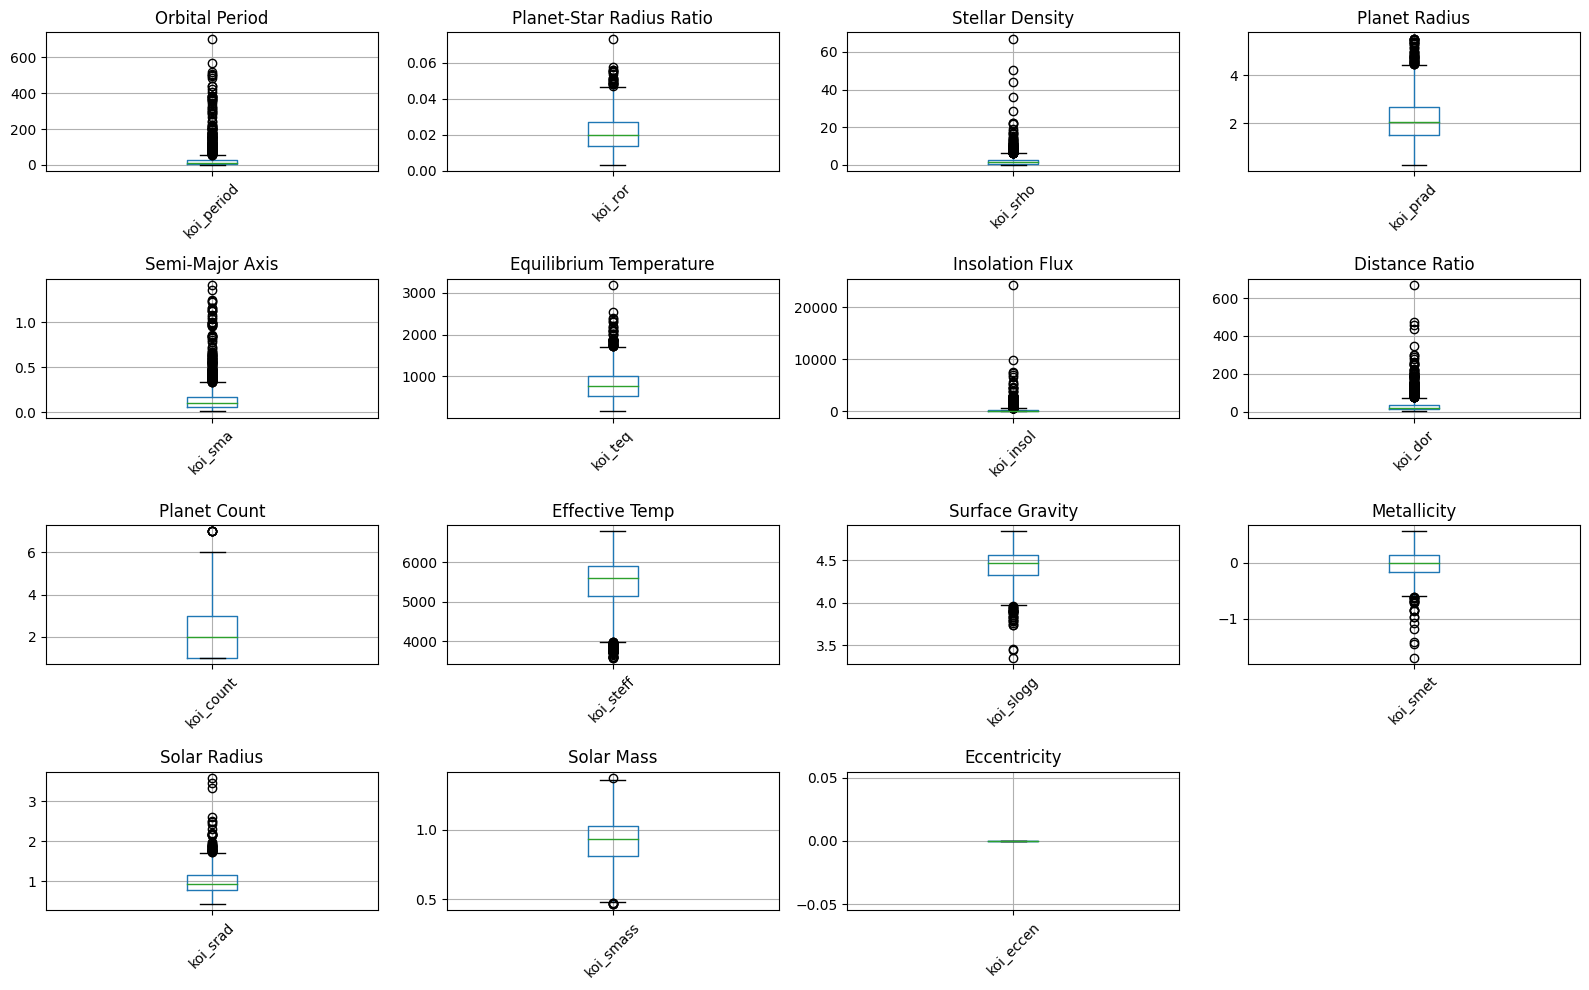

In [38]:
## Distribution of numerical columns


columns_to_plot = [
    "koi_period", "koi_ror", "koi_srho", "koi_prad",
    "koi_sma", "koi_teq", "koi_insol", "koi_dor",
    "koi_count", "koi_steff", "koi_slogg", "koi_smet",
    "koi_srad", "koi_smass", "koi_eccen"
]

# Create subplots (3 rows, 4 columns)
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(16, 10))
axes = axes.flatten()  # Flatten the grid to loop easily

columns_titles = [
    "Orbital Period", "Planet-Star Radius Ratio", "Stellar Density",
    "Planet Radius", "Semi-Major Axis", "Equilibrium Temperature",
    "Insolation Flux", "Distance Ratio", "Planet Count",
    "Effective Temp", "Surface Gravity", "Metallicity", "Solar Radius",
    "Solar Mass", "Eccentricity"
]

# Plot each boxplot
for i, col in enumerate(columns_to_plot):
    X_train.boxplot(column=col, ax=axes[i])
    axes[i].set_title(columns_titles[i])
    axes[i].tick_params(axis='x', labelrotation=45)

# Remove any unused subplots (if fewer than 12)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## Imputation

In [39]:
X_train.isnull().sum()

koi_period    0
koi_ror       0
koi_srho      0
koi_prad      0
koi_sma       0
koi_teq       0
koi_insol     0
koi_dor       0
koi_count     0
koi_steff     0
koi_slogg     0
koi_smet      0
koi_srad      0
koi_smass     0
koi_eccen     0
dtype: int64

In [40]:
median_imputation_cols = [
    "koi_period", "koi_ror", "koi_srho", "koi_prad",
    "koi_sma", "koi_teq", "koi_insol", "koi_dor",
    "koi_count", "koi_steff", "koi_slogg", "koi_smet",
    "koi_srad", "koi_smass", "koi_eccen"
]

from sklearn.impute import SimpleImputer

# create the imputer

median_imputer = SimpleImputer(strategy = 'median')

# impute

X_train.loc[:, median_imputation_cols] = median_imputer.fit_transform(X_train[median_imputation_cols])

In [41]:
X_test.isnull().sum()

koi_period    0
koi_ror       0
koi_srho      0
koi_prad      0
koi_sma       0
koi_teq       0
koi_insol     0
koi_dor       0
koi_count     0
koi_steff     0
koi_slogg     0
koi_smet      0
koi_srad      0
koi_smass     0
koi_eccen     0
dtype: int64

In [42]:


X_test.loc[:, median_imputation_cols] = median_imputer.transform(X_test[median_imputation_cols])



In [43]:
X_test.isnull().sum()

koi_period    0
koi_ror       0
koi_srho      0
koi_prad      0
koi_sma       0
koi_teq       0
koi_insol     0
koi_dor       0
koi_count     0
koi_steff     0
koi_slogg     0
koi_smet      0
koi_srad      0
koi_smass     0
koi_eccen     0
dtype: int64

## Model: Logistic Regression

Since its a classification problem it is natural to start with Logistic regression as my first model. It is simple and with penalties accounts for a large amount of noise as well which, as I mentioned earlier, might be present in the model. Below I will be comparing logistic regression models with different penalties (L1, L2 and both) and at the end taking the model which gives the best cross validated F1 score

In [44]:
# Shared C values
C_values = np.logspace(-4, 3, 25)

# Initialize dictionary to store grid searches and results
log_reg_results = {}

### Lasso

In [45]:

log_reg_l1_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(penalty='l1', solver='liblinear', max_iter=2500))
])

log_reg_l1_grid = GridSearchCV(
    estimator=log_reg_l1_pipeline,
    param_grid={'logreg__C': C_values},
    cv=5,
    scoring='f1_macro',
    n_jobs=-1,
    return_train_score=True
)

log_reg_l1_grid.fit(X_train, y_train)



GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('logreg',
                                        LogisticRegression(max_iter=2500,
                                                           penalty='l1',
                                                           solver='liblinear'))]),
             n_jobs=-1,
             param_grid={'logreg__C': array([1.00000000e-04, 1.95734178e-04, 3.83118685e-04, 7.49894209e-04,
       1.46779927e-03, 2.87298483e-03, 5.62341325e-03, 1.10069417e-02,
       2.15443469e-02, 4.21696503e-02, 8.25404185e-02, 1.61559810e-01,
       3.16227766e-01, 6.18965819e-01, 1.21152766e+00, 2.37137371e+00,
       4.64158883e+00, 9.08517576e+00, 1.77827941e+01, 3.48070059e+01,
       6.81292069e+01, 1.33352143e+02, 2.61015722e+02, 5.10896977e+02,
       1.00000000e+03])},
             return_train_score=True, scoring='f1_macro')

In [46]:
log_reg_l1_best_model = log_reg_l1_grid.best_estimator_
log_reg_l1_y_pred = log_reg_l1_best_model.predict(X_test)
log_reg_results['L1'] = log_reg_l1_grid

print("Logistic Regression (L1)")
print("Best C:", log_reg_l1_grid.best_params_['logreg__C'])
print("CV Macro F1:", round(log_reg_l1_grid.best_score_, 4))


Logistic Regression (L1)
Best C: 133.3521432163324
CV Macro F1: 0.9409


In [47]:
print(classification_report(y_test, log_reg_l1_y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       403
           1       0.92      1.00      0.96        22

    accuracy                           1.00       425
   macro avg       0.96      1.00      0.98       425
weighted avg       1.00      1.00      1.00       425



### Ridge

In [48]:

log_reg_l2_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(penalty='l2', solver='liblinear', max_iter=2500))
])

log_reg_l2_grid = GridSearchCV(
    estimator=log_reg_l2_pipeline,
    param_grid={'logreg__C': C_values},
    cv=5,
    scoring='f1_macro',
    n_jobs=-1,
    return_train_score=True
)

log_reg_l2_grid.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('logreg',
                                        LogisticRegression(max_iter=2500,
                                                           solver='liblinear'))]),
             n_jobs=-1,
             param_grid={'logreg__C': array([1.00000000e-04, 1.95734178e-04, 3.83118685e-04, 7.49894209e-04,
       1.46779927e-03, 2.87298483e-03, 5.62341325e-03, 1.10069417e-02,
       2.15443469e-02, 4.21696503e-02, 8.25404185e-02, 1.61559810e-01,
       3.16227766e-01, 6.18965819e-01, 1.21152766e+00, 2.37137371e+00,
       4.64158883e+00, 9.08517576e+00, 1.77827941e+01, 3.48070059e+01,
       6.81292069e+01, 1.33352143e+02, 2.61015722e+02, 5.10896977e+02,
       1.00000000e+03])},
             return_train_score=True, scoring='f1_macro')

In [49]:
log_reg_l2_best_model = log_reg_l2_grid.best_estimator_
log_reg_l2_y_pred = log_reg_l2_best_model.predict(X_test)
log_reg_results['L2'] = log_reg_l2_grid

print("Logistic Regression (L2)")
print("Best C:", log_reg_l2_grid.best_params_['logreg__C'])
print("CV Macro F1:", round(log_reg_l2_grid.best_score_, 4))

Logistic Regression (L2)
Best C: 1000.0
CV Macro F1: 0.9384


In [50]:
print(classification_report(y_test, log_reg_l2_y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       403
           1       0.92      1.00      0.96        22

    accuracy                           1.00       425
   macro avg       0.96      1.00      0.98       425
weighted avg       1.00      1.00      1.00       425



### Elastic Net

In [51]:

log_reg_en_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(penalty='elasticnet', solver='saga', max_iter=5000))
])

log_reg_en_grid = GridSearchCV(
    estimator=log_reg_en_pipeline,
    param_grid={
        'logreg__C': C_values,
        'logreg__l1_ratio': [0.5]
    },
    cv=5,
    scoring='f1_macro',
    n_jobs=-1,
    return_train_score=True
)

log_reg_en_grid.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('logreg',
                                        LogisticRegression(max_iter=5000,
                                                           penalty='elasticnet',
                                                           solver='saga'))]),
             n_jobs=-1,
             param_grid={'logreg__C': array([1.00000000e-04, 1.95734178e-04, 3.83118685e-04, 7.49894209e-04,
       1.46779927e-03, 2.87298483e-03, 5.62341325e-03, 1.10069417e-02,
       2.15443469e-02, 4.21696503e-02, 8.25404185e-02, 1.61559810e-01,
       3.16227766e-01, 6.18965819e-01, 1.21152766e+00, 2.37137371e+00,
       4.64158883e+00, 9.08517576e+00, 1.77827941e+01, 3.48070059e+01,
       6.81292069e+01, 1.33352143e+02, 2.61015722e+02, 5.10896977e+02,
       1.00000000e+03]),
                         'logreg__l1_ratio': [0.5]},
             return_train_score=True, scoring='f1_macro')

Since Elastic net below gives the best F1 score, I shall be using it as the best performing logistic regression model

In [52]:
log_reg_en_best_model = log_reg_en_grid.best_estimator_
log_reg_en_y_pred = log_reg_en_best_model.predict(X_test)
log_reg_results['Elastic Net'] = log_reg_en_grid

print("Logistic Regression (Elastic Net)")
print("Best C:", log_reg_en_grid.best_params_['logreg__C'])
print("CV Macro F1:", round(log_reg_en_grid.best_score_, 4))

Logistic Regression (Elastic Net)
Best C: 9.08517575651688
CV Macro F1: 0.9419


In [53]:
print(classification_report(y_test, log_reg_en_y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       403
           1       0.91      0.95      0.93        22

    accuracy                           0.99       425
   macro avg       0.96      0.97      0.96       425
weighted avg       0.99      0.99      0.99       425



In [54]:
# Best model for logistic regression (Elasticnet - With L1 and L2 penalties)
log_reg_best_model = log_reg_en_grid.best_estimator_
log_reg_best_score = log_reg_en_grid.best_score_
print("Best C (1/lambda) for Logistic Regression:", log_reg_en_grid.best_params_['logreg__C'])
print("Best lambda for Logistic Regression:", 1/log_reg_en_grid.best_params_['logreg__C'])
print("Best Cross-Validated Macro F1 Score:", round(log_reg_en_grid.best_score_, 4))
print("Best penalty to use: Combination of L1 and L2 Norm Penalties - Combination of Ridge and Lasso - Elastic Net")

Best C (1/lambda) for Logistic Regression: 9.08517575651688
Best lambda for Logistic Regression: 0.1100694171252208
Best Cross-Validated Macro F1 Score: 0.9419
Best penalty to use: Combination of L1 and L2 Norm Penalties - Combination of Ridge and Lasso - Elastic Net


In [55]:
# Evaluate on test data
log_reg_y_pred = log_reg_best_model.predict(X_test)

In [56]:
print("\nClassification Report (Test Data):")
print(classification_report(y_test, log_reg_y_pred))


Classification Report (Test Data):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       403
           1       0.91      0.95      0.93        22

    accuracy                           0.99       425
   macro avg       0.96      0.97      0.96       425
weighted avg       0.99      0.99      0.99       425



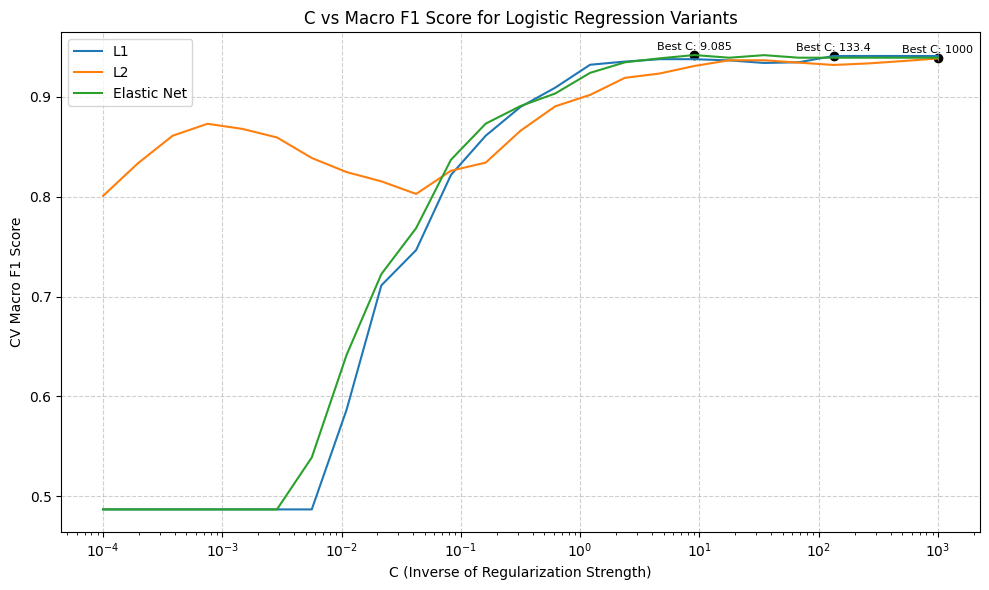

In [57]:

plt.figure(figsize=(10, 6))

for label, grid in log_reg_results.items():
    C_vals = grid.param_grid['logreg__C']
    mean_scores = grid.cv_results_['mean_test_score']
    
    # Find the best C and its score
    best_index = np.argmax(mean_scores)
    best_C = C_vals[best_index]
    best_score = mean_scores[best_index]
    
    # Plot the full F1 curve
    plt.plot(C_vals, mean_scores, label=f'{label}')
    
    # Mark the best C
    plt.scatter(best_C, best_score, marker='o', color='black')
    plt.text(best_C, best_score + 0.005, f'Best C: {best_C:.4g}', fontsize=8, ha='center')

plt.xscale('log')
plt.xlabel('C (Inverse of Regularization Strength)')
plt.ylabel('CV Macro F1 Score')
plt.title('C vs Macro F1 Score for Logistic Regression Variants')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## Model: Random Forest (Without Boosting)

Naturally next I shall be trying Random forests. Below I am also plotting the feature importance given by Random Forest

In [58]:



rf_pipeline = Pipeline([
    ('rf', RandomForestClassifier(random_state=42))
])


In [59]:
rf_param_grid = {
    'rf__n_estimators': [100, 200, 300],
    "rf__max_features": [4, "sqrt", "log2", 10],
    'rf__max_depth': [2, 5, 10],
    'rf__min_samples_split': [2, 5, 10]
}

In [60]:



rf_grid_search = GridSearchCV(rf_pipeline, rf_param_grid, cv=5, scoring='f1_macro', n_jobs=-1)
rf_grid_search.fit(X_train, y_train)



GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('rf',
                                        RandomForestClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'rf__max_depth': [2, 5, 10],
                         'rf__max_features': [4, 'sqrt', 'log2', 10],
                         'rf__min_samples_split': [2, 5, 10],
                         'rf__n_estimators': [100, 200, 300]},
             scoring='f1_macro')

In [61]:
rf_best_model = rf_grid_search.best_estimator_
rf_y_pred = rf_best_model.predict(X_test)

print("Random Forest Best Params:", rf_grid_search.best_params_)
print("Random Forest F1 (CV):", round(rf_grid_search.best_score_, 4))


Random Forest Best Params: {'rf__max_depth': 10, 'rf__max_features': 4, 'rf__min_samples_split': 5, 'rf__n_estimators': 200}
Random Forest F1 (CV): 0.9718


In [62]:
print(classification_report(y_test, rf_y_pred))

              precision    recall  f1-score   support

           0       1.00      0.99      1.00       403
           1       0.88      0.95      0.91        22

    accuracy                           0.99       425
   macro avg       0.94      0.97      0.95       425
weighted avg       0.99      0.99      0.99       425



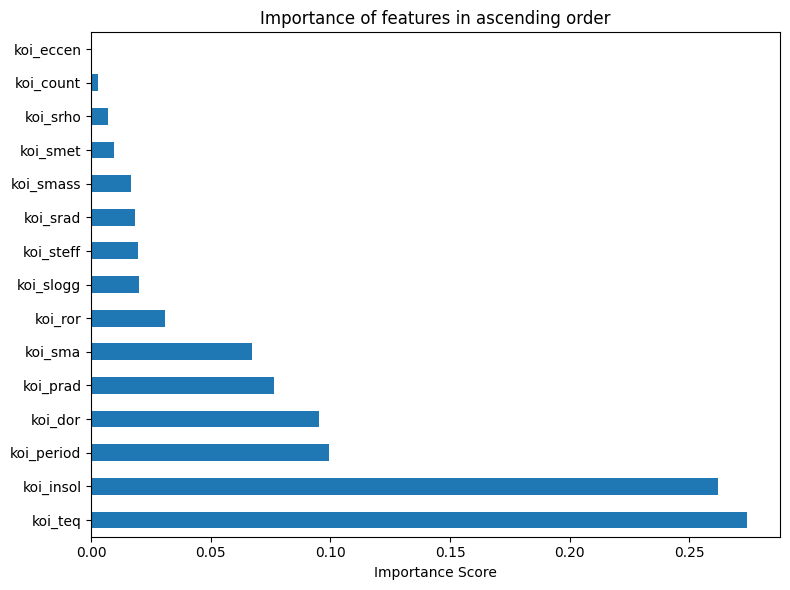

In [63]:

# Access the actual classifier inside the pipeline
rf_model = rf_best_model.named_steps['rf']

# Create series with feature importances
feature_importance_random_forest = pd.Series(
    rf_model.feature_importances_,
    index=X_train.columns
)

# Plot top 15 features
feature_importance_random_forest.nlargest(15).plot(kind='barh', figsize=(8, 6))
plt.title('Importance of features in ascending order')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

In [64]:
# Sort feature importances
sorted_importance_random_forest = feature_importance_random_forest.sort_values(ascending=False)

# Most important feature
most_important_random_forest = sorted_importance_random_forest.index[0]
most_important_value_random_forest = sorted_importance_random_forest.iloc[0]

# Least important feature
least_important_random_forest = sorted_importance_random_forest.index[-1]
least_important_value_random_forest = sorted_importance_random_forest.iloc[-1]

# Print the results
print(f"Most important feature (Random Forest): {most_important_random_forest} ({most_important_value_random_forest:.4f})")
print(f"Least important feature (Random Forest): {least_important_random_forest} ({least_important_value_random_forest:.4f})")

Most important feature (Random Forest): koi_teq (0.2742)
Least important feature (Random Forest): koi_eccen (0.0000)


As seen above the random forest model gives high importance to the equillibrium temperature and the insolation flux (energy recieved from the sun per square length) -- it makes sense that these are two important parameters becase temperature is crucial for life. This is what has led to habitable zones being called "Goldilocks" zones.

## Model: Random Forest with Gradient Boosting

Next, I shall be performing the same analysis but with Gradient Boosting

In [65]:
gbm_pipeline = Pipeline([
    ('gbm', GradientBoostingClassifier(random_state=42))
])

In [66]:

param_grid_boosting = {
    'gbm__n_estimators': [100, 200, 300],
    'gbm__learning_rate': [0.01, 0.05, 0.1, 0.5]
}

In [67]:
gbm_grid_search = GridSearchCV(
    gbm_pipeline,
    param_grid_boosting,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)

In [68]:
gbm_grid_search.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('gbm',
                                        GradientBoostingClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'gbm__learning_rate': [0.01, 0.05, 0.1, 0.5],
                         'gbm__n_estimators': [100, 200, 300]},
             scoring='f1_macro')

In [69]:
gbm_best_model = gbm_grid_search.best_estimator_
gbm_y_pred = gbm_best_model.predict(X_test)

print("GBM Best Params:", gbm_grid_search.best_params_)
print("GBM F1 (CV):", round(gbm_grid_search.best_score_, 4))

GBM Best Params: {'gbm__learning_rate': 0.5, 'gbm__n_estimators': 100}
GBM F1 (CV): 0.972


In [70]:
print(classification_report(y_test, gbm_y_pred))

              precision    recall  f1-score   support

           0       1.00      0.99      1.00       403
           1       0.88      0.95      0.91        22

    accuracy                           0.99       425
   macro avg       0.94      0.97      0.95       425
weighted avg       0.99      0.99      0.99       425



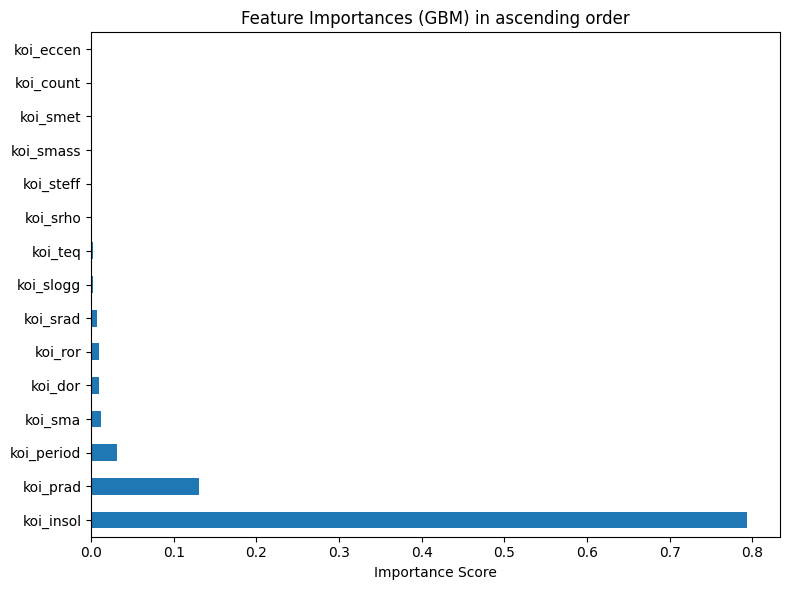

In [71]:


# Access the trained classifier from the pipeline
gbm_model = gbm_best_model.named_steps['gbm']

# Create a Series with feature importances
feature_importance_gbm = pd.Series(
    gbm_model.feature_importances_,
    index=X_train.columns
)

# Plot the top 15 features
feature_importance_gbm.nlargest(15).plot(kind='barh', figsize=(8, 6))
plt.title('Feature Importances (GBM) in ascending order')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

In [72]:
# Sort importances
sorted_importance_gbm = feature_importance_gbm.sort_values(ascending=False)

# Most important
most_important_gbm = sorted_importance_gbm.index[0]
most_important_value_gbm = sorted_importance_gbm.iloc[0]

# Least important
least_important_gbm = sorted_importance_gbm.index[-1]
least_important_value_gbm = sorted_importance_gbm.iloc[-1]

# Print results
print(f"Most important feature (GBM): {most_important_gbm} ({most_important_value_gbm:.4f})")
print(f"Least important feature (GBM): {least_important_gbm} ({least_important_value_gbm:.4f})")

Most important feature (GBM): koi_insol (0.7938)
Least important feature (GBM): koi_eccen (0.0000)


Curiously, above the insolation flux becomes a huge factor. This is not unexpected and is supported by literature but this behaviour means that the previous random forest model must have a little bit overfitting.

## Model: XGBoosting

Next I shall perform XG Boosting and a model analysis for the same

In [73]:

xgb_pipeline = Pipeline([
    ('xgb', XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42))
])

In [74]:

xgb_param_grid = {
    'xgb__n_estimators': [100, 200, 300],
    'xgb__max_depth': [2, 5, 10],
    'xgb__learning_rate': [0.01, 0.1, 0.5, 1]
}

In [75]:
xgb_grid_search = GridSearchCV(xgb_pipeline, xgb_param_grid, cv=5, scoring='f1_macro', n_jobs=-1)
xgb_grid_search.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('xgb',
                                        XGBClassifier(base_score=None,
                                                      booster=None,
                                                      callbacks=None,
                                                      colsample_bylevel=None,
                                                      colsample_bynode=None,
                                                      colsample_bytree=None,
                                                      device=None,
                                                      early_stopping_rounds=None,
                                                      enable_categorical=False,
                                                      eval_metric='logloss',
                                                      feature_types=None,
                                                      gamma=None,
                                                      grow_policy=None,
                                                      importance_type=None,
                                                      interaction_constrai...
                                                      max_cat_to_onehot=None,
                                                      max_delta_step=None,
                                                      max_depth=None,
                                                      max_leaves=None,
                                                      min_child_weight=None,
                                                      missing=nan,
                                                      monotone_constraints=None,
                                                      multi_strategy=None,
                                                      n_estimators=None,
                                                      n_jobs=None,
                                                      num_parallel_tree=None,
                                                      random_state=42, ...))]),
             n_jobs=-1,
             param_grid={'xgb__learning_rate': [0.01, 0.1, 0.5, 1],
                         'xgb__max_depth': [2, 5, 10],
                         'xgb__n_estimators': [100, 200, 300]},
             scoring='f1_macro')

In [76]:
xgb_best_model = xgb_grid_search.best_estimator_
xgb_y_pred = xgb_best_model.predict(X_test)

In [77]:
print("XGBoost Best Params:", xgb_grid_search.best_params_)
print("XGBoost F1 (CV):", round(xgb_grid_search.best_score_, 4))

XGBoost Best Params: {'xgb__learning_rate': 0.01, 'xgb__max_depth': 2, 'xgb__n_estimators': 100}
XGBoost F1 (CV): 0.9647


In [78]:
print(classification_report(y_test, xgb_y_pred))

              precision    recall  f1-score   support

           0       1.00      0.99      0.99       403
           1       0.87      0.91      0.89        22

    accuracy                           0.99       425
   macro avg       0.93      0.95      0.94       425
weighted avg       0.99      0.99      0.99       425



## Model: SVM Linear

The final models I am considering are support vector machines -- since they are usually ideal for classification problems. I am starting with linear SVMs but moving on to polynomial and RBF kernels -- I have high hopes for RBF due to the high accuracy it provides while classifying

In [79]:
# SVM - Linear
svm_linear_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='linear'))
])

In [80]:
svm_linear_param_grid = {
    'svm__C': [0.01, 0.1, 1, 10, 100],
}

In [81]:
svm_linear_grid_search = GridSearchCV(
    svm_linear_pipeline,
    svm_linear_param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)

In [82]:
svm_linear_grid_search.fit(X_train, y_train)


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('svm', SVC(kernel='linear'))]),
             n_jobs=-1, param_grid={'svm__C': [0.01, 0.1, 1, 10, 100]},
             scoring='f1_macro')

In [83]:
svm_linear_best_model = svm_linear_grid_search.best_estimator_
svm_linear_y_pred = svm_linear_best_model.predict(X_test)

In [84]:
print("SVM (Linear) Best Params:", svm_linear_grid_search.best_params_)
print("SVM (Linear) F1 (CV):", round(svm_linear_grid_search.best_score_, 4))

SVM (Linear) Best Params: {'svm__C': 10}
SVM (Linear) F1 (CV): 0.9419


In [85]:
print(classification_report(y_test, svm_linear_y_pred))

              precision    recall  f1-score   support

           0       1.00      0.99      1.00       403
           1       0.88      0.95      0.91        22

    accuracy                           0.99       425
   macro avg       0.94      0.97      0.95       425
weighted avg       0.99      0.99      0.99       425



## Model: SVM Polynomial

In [86]:
# SVM - Polynomial
svm_poly_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='poly'))
])

In [87]:
svm_poly_param_grid = {
    'svm__C': [0.1, 1, 10],
    'svm__degree': [2, 3, 4],
    'svm__gamma': ['auto'] ## Keeping to gamma auto to avoid overfitting
}

In [88]:
svm_poly_grid_search = GridSearchCV(
    svm_poly_pipeline,
    svm_poly_param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)

In [89]:
svm_poly_grid_search.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('svm', SVC(kernel='poly'))]),
             n_jobs=-1,
             param_grid={'svm__C': [0.1, 1, 10], 'svm__degree': [2, 3, 4],
                         'svm__gamma': ['auto']},
             scoring='f1_macro')

In [90]:
svm_poly_best_model = svm_poly_grid_search.best_estimator_
svm_poly_y_pred = svm_poly_best_model.predict(X_test)

print(" SVM (Poly) Best Params:", svm_poly_grid_search.best_params_)
print(" SVM (Poly) F1 (CV):", round(svm_poly_grid_search.best_score_, 4))

 SVM (Poly) Best Params: {'svm__C': 10, 'svm__degree': 2, 'svm__gamma': 'auto'}
 SVM (Poly) F1 (CV): 0.9399


In [91]:
print(classification_report(y_test, svm_poly_y_pred))

              precision    recall  f1-score   support

           0       1.00      0.99      0.99       403
           1       0.81      0.95      0.88        22

    accuracy                           0.99       425
   macro avg       0.90      0.97      0.93       425
weighted avg       0.99      0.99      0.99       425



## Model: SVM - Radial Basis Functions

In [92]:
# SVM - RBF
svm_rbf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='rbf'))
])

In [93]:
svm_rbf_param_grid = {
    'svm__C': [0.1, 1, 10, 100],
    'svm__gamma': [0.01, 0.1, 1, 10]
}

In [94]:
svm_rbf_grid_search = GridSearchCV(
    svm_rbf_pipeline,
    svm_rbf_param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)

In [95]:
svm_rbf_grid_search.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('svm', SVC())]),
             n_jobs=-1,
             param_grid={'svm__C': [0.1, 1, 10, 100],
                         'svm__gamma': [0.01, 0.1, 1, 10]},
             scoring='f1_macro')

In [96]:
svm_rbf_best_model = svm_rbf_grid_search.best_estimator_
svm_rbf_y_pred = svm_rbf_best_model.predict(X_test)

In [97]:
print("SVM (RBF) Best Params:", svm_rbf_grid_search.best_params_)
print("SVM (RBF) F1 (CV):", round(svm_rbf_grid_search.best_score_, 4))

SVM (RBF) Best Params: {'svm__C': 10, 'svm__gamma': 0.01}
SVM (RBF) F1 (CV): 0.9421


In [98]:
print(classification_report(y_test, svm_rbf_y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       403
           1       0.91      0.95      0.93        22

    accuracy                           0.99       425
   macro avg       0.96      0.97      0.96       425
weighted avg       0.99      0.99      0.99       425



# Model Comparison

In [99]:
# Define models and their corresponding grid searches
model_info = {
    'Logistic Regression (Elastic Net)': ('log_reg_best_model', 'log_reg_en_grid'),
    'Random Forest': ('rf_best_model', 'rf_grid_search'),
    'Random Forest With GBM': ('gbm_best_model', 'gbm_grid_search'),
    'XGBoost': ('xgb_best_model', 'xgb_grid_search'),
    'SVM (Linear)': ('svm_linear_best_model', 'svm_linear_grid_search'),
    'SVM (Poly)': ('svm_poly_best_model', 'svm_poly_grid_search'),
    'SVM (RBF)': ('svm_rbf_best_model', 'svm_rbf_grid_search')
}

In [100]:
# Initialize results list
summary_data = []

In [101]:
# Loop through each model
for name, (model_var, grid_var) in model_info.items():
    # Get model and grid search from globals
    model = globals()[model_var]
    grid = globals()[grid_var]
    
    # Predict on test set
    y_pred = model.predict(X_test)
    
    # Collect CV and test scores
    cv_score = grid.best_score_
    test_score = f1_score(y_test, y_pred, average='macro')
    
    # Append results
    summary_data.append({
        'Model': name,
        'CV F1 (macro)': round(cv_score, 4),
        'Test F1 (macro)': round(test_score, 4)
    })

In [102]:
# Create and display DataFrame
summary_df = pd.DataFrame(summary_data)
print(" Model Performance Summary:")
print(summary_df)

 Model Performance Summary:
                               Model  CV F1 (macro)  Test F1 (macro)
0  Logistic Regression (Elastic Net)         0.9419           0.9648
1                      Random Forest         0.9718           0.9540
2             Random Forest With GBM         0.9720           0.9540
3                            XGBoost         0.9647           0.9413
4                       SVM (Linear)         0.9419           0.9540
5                         SVM (Poly)         0.9399           0.9338
6                          SVM (RBF)         0.9421           0.9648


## Comparisons and Cnclusions

Having identified a set of fifteen foundational features observable through telescopic means—such as orbital period, stellar temperature, planetary radius, and orbital eccentricity—I proceeded to evaluate a number of classification models to determine which might be most effective in predicting the habitability of exoplanets. These features represent the primary physical characteristics of both the planet and its host star, and were selected for their accessibility and relevance to early-stage habitability assessment. A key objective was not just to assess performance in terms of accuracy, but also to understand how different models behave in relation to overfitting, generalization, model flexibility, and interpretability.

Logistic Regression with Elastic Net regularization emerged as one of the strongest performers, achieving the highest macro F1 score on the test data (0.9648). The Elastic Net formulation strikes a balance between L1 (lasso) and L2 (ridge) penalties, enabling it to both shrink irrelevant coefficients and stabilize those that are moderately informative. From a bias-variance standpoint, this model sits comfortably in the middle: it maintains a relatively low bias due to its linear form while reducing variance through regularization. It also avoids overfitting despite its simplicity, and its interpretability is one of its major strengths. The coefficients provide a transparent look into which features influence the classification outcome—an advantage that is particularly meaningful in scientific contexts such as exoplanet research, where interpretability may support domain insights and validation.

Support Vector Machine with an RBF kernel matched Elastic Net’s test performance (also 0.9648), indicating that there may be some non-linear structure within the data, though not substantial enough to warrant more complex transformations. The RBF kernel introduces more flexibility than a linear model, allowing the classifier to draw non-linear boundaries in the feature space. This increased flexibility reduces bias but comes at the cost of higher variance and lower interpretability. Unlike the Elastic Net model, the SVM does not readily offer insights into feature importance or decision logic, making it more of a black box. Nonetheless, its capacity to generalize well suggests that it captures subtle structures in the data without succumbing to overfitting.

Tree-based ensemble methods—namely Random Forest and Gradient Boosting Machines (GBM)—achieved the highest cross-validation F1 scores (approximately 0.972), but their performance on the test set dropped slightly to 0.954. This gap suggests moderate overfitting: the models are likely capturing interactions and patterns in the training folds that do not fully generalize to unseen data. Both models operate in the low-bias, high-variance region of the bias-variance spectrum, especially when allowed deep trees and many estimators. While this flexibility allows them to model complex, non-linear relationships and feature interactions, it also makes them prone to fitting noise. In terms of interpretability, Random Forests provide feature importance scores that are relatively straightforward to interpret, though the overall decision process is more opaque than that of a logistic model. GBMs, though slightly more performant during training, are even less interpretable without specialized tools such as SHAP values or partial dependence plots.

XGBoost, another gradient boosting implementation, underperformed relative to Random Forest and GBM, with a test F1 score of 0.9413 despite a cross-validation score of 0.9647. This drop in generalization suggests that the model may either be overfitting due to insufficient regularization or not yet optimally tuned. Its high flexibility implies that it has low bias, but its generalization gap points to higher variance. Like GBM, it suffers from reduced interpretability and requires additional methods to extract meaningful feature-level insights.

SVM with a linear kernel delivered solid and stable performance (test F1 score of 0.9540), similar to Random Forest. Its place in the bias-variance tradeoff is similar to Elastic Net: relatively low variance due to its linear constraints, but with slightly higher bias in cases where non-linear boundaries are present. It offers moderate interpretability through its weight vector, though not as directly as logistic regression. This model supports the hypothesis that the data's decision boundary is not strongly non-linear.

SVM with a polynomial kernel performed the weakest overall, with both cross-validation and test scores lower than other models (test F1 score of 0.9338). This suggests that the additional flexibility introduced by polynomial transformations resulted in overfitting without added benefit. In bias-variance terms, this model is high variance and low bias, but inappropriately so for the structure of the data. It is also the least interpretable of the SVM variants due to the complexity of the polynomial decision boundary.

In summary, Logistic Regression with Elastic Net regularization provides the most balanced and interpretable solution, achieving excellent generalization performance without the risk of overfitting. SVM with an RBF kernel also performs strongly but trades off interpretability for flexibility. Tree-based methods, while powerful, show signs of overfitting and require additional care in tuning and explaining results. XGBoost falls short of expectations likely due to insufficient regularization. SVM with a linear kernel confirms the effectiveness of linear models in this setting, and the polynomial kernel variant appears unnecessarily complex. These findings are promising, as they suggest that even a reduced and observationally accessible feature set can yield strong predictive performance when paired with appropriately regularized models. This supports the feasibility of using machine learning to assist in early-stage habitability classification, allowing astronomers to focus their observational resources on the most promising planetary candidates.

# Attibutions and useful links:
1. https://exoplanetarchive.ipac.caltech.edu/docs/data.html
2. https://doi.org/10.1073/pnas.130419711
3. Eur. Phys. J. Spec. Top. (2021) 230:2221–2251
https://doi.org/10.1140/epjs/s11734-021-00203-z
4. https://github.com/rkmisra/cs229_project/
5. https://phl.upr.edu/hwc/data